# Week 7 Tutorial - Feature Engineering

**How to use this notebook:**
Read one section of `study-guide.md`, then do that section here before moving on.

Each section has:
- A worked example (pre-written - just run it)
- A **DO IT YOURSELF** cell with different data

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# California housing for regression examples
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['target'] = housing.target

# Wine for classification do-it-yourself
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target

print('Housing dataset shape:', df_housing.shape)
print('Wine dataset shape:', df_wine.shape)
print()
print(df_housing.head())

Housing dataset shape: (20640, 9)
Wine dataset shape: (178, 14)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


---
## Section 1 - Encoding Categorical Variables
### EXAMPLE

In [5]:
# EXAMPLE: one-hot encoding vs ordinal encoding on a synthetic dataset

df = pd.DataFrame({
    'city':  ['NYC', 'LA', 'NYC', 'Chicago', 'LA', 'NYC', 'Chicago'],
    'size':  ['small', 'large', 'medium', 'small', 'large', 'medium', 'small'],
    'price': [500, 300, 450, 250, 320, 470, 240]
})

print('Original:')
print(df)
print()

# One-hot encoding for city (no natural order)
df_encoded = pd.get_dummies(df, columns=['city'], prefix='city')

# Ordinal encoding for size (has natural order: small < medium < large)
size_order = {'small': 0, 'medium': 1, 'large': 2}
df_encoded['size_ordinal'] = df['size'].map(size_order)
df_encoded = df_encoded.drop('size', axis=1)

print('After encoding:')
print(df_encoded)

Original:
      city    size  price
0      NYC   small    500
1       LA   large    300
2      NYC  medium    450
3  Chicago   small    250
4       LA   large    320
5      NYC  medium    470
6  Chicago   small    240

After encoding:
   price  city_Chicago  city_LA  city_NYC  size_ordinal
0    500         False    False      True             0
1    300         False     True     False             2
2    450         False    False      True             1
3    250          True    False     False             0
4    320         False     True     False             2
5    470         False    False      True             1
6    240          True    False     False             0


### DO IT YOURSELF - Section 1
Dataset: synthetic customer data (below)

1. Apply one-hot encoding to `country` (no natural order)
2. Apply ordinal encoding to `satisfaction` (low < medium < high)
3. Print the result

In [8]:
df_customers = pd.DataFrame({
    'country':      ['USA', 'UK', 'USA', 'Canada', 'UK', 'Canada'],
    'satisfaction': ['high', 'low', 'medium', 'high', 'medium', 'low'],
    'spent':        [200, 80, 150, 220, 130, 75]
})

# DO IT YOURSELF - Section 1
# YOUR CODE HERE
print('Original:')
print(df_customers)
print()

df_customers_encode = pd.get_dummies(df_customers, columns=['country'], prefix='country')
satisfaction_order = {'low': 0, 'medium': 1, 'high': 2}
df_customers_encode['satisfaction_ordinal'] = df_customers['satisfaction'].map(satisfaction_order)
df_customers_encode = df_customers_encode.drop('satisfaction', axis=1)

print('After encoding')
print(df_customers_encode)

Original:
  country satisfaction  spent
0     USA         high    200
1      UK          low     80
2     USA       medium    150
3  Canada         high    220
4      UK       medium    130
5  Canada          low     75

After encoding
   spent  country_Canada  country_UK  country_USA  satisfaction_ordinal
0    200           False       False         True                     2
1     80           False        True        False                     0
2    150           False       False         True                     1
3    220            True       False        False                     2
4    130           False        True        False                     1
5     75            True       False        False                     0


---
## Section 2 - Handling Skewed Distributions
### EXAMPLE

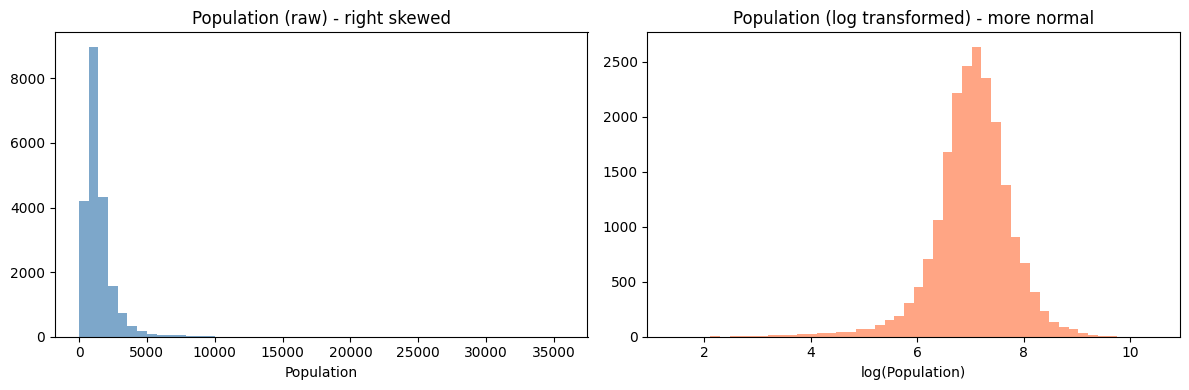

R2 without log transform: 0.1363
R2 with log transform:    0.0904
       Population  AveRooms  AveBedrms
14196      2300.0  5.017657   1.006421
8267       1314.0  4.473545   1.041005
17445       915.0  5.645833   0.985119
14265      1418.0  4.002817   1.033803
2271        874.0  6.268421   1.134211
...           ...       ...        ...
11284       658.0  6.129032   0.926267
11964      1753.0  6.868597   1.269488
5390       1756.0  3.986717   1.079696
860        1777.0  6.395349   1.067979
15795      2619.0  3.402576   1.058776

[16512 rows x 3 columns]


In [10]:
# EXAMPLE: log transform on housing population feature

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw population - skewed
axes[0].hist(df_housing['Population'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Population (raw) - right skewed')
axes[0].set_xlabel('Population')

# Log transformed
axes[1].hist(np.log1p(df_housing['Population']), bins=50, color='coral', alpha=0.7)
axes[1].set_title('Population (log transformed) - more normal')
axes[1].set_xlabel('log(Population)')

plt.tight_layout()
plt.show()

# Compare model performance with and without log transform
from sklearn.linear_model import LinearRegression

X = df_housing[['Population', 'AveRooms', 'AveBedrms']]
X_log = X.copy()
X_log['Population'] = np.log1p(X['Population'])
X_log['AveRooms']   = np.log1p(X['AveRooms'])
y = df_housing['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_log_train, X_log_test = X_log.iloc[X_train.index], X_log.iloc[X_test.index]

lr = LinearRegression()
score_raw = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2').mean()
score_log = cross_val_score(lr, X_log_train, y_train, cv=5, scoring='r2').mean()

print(f'R2 without log transform: {score_raw:.4f}')
print(f'R2 with log transform:    {score_log:.4f}')

print(X_train)

### DO IT YOURSELF - Section 2
Dataset: wine

1. Plot histograms for `proline` and `alcohol` features (raw)
2. Apply log transform to `proline` (it is right-skewed)
3. Plot the transformed distribution next to the raw one
4. Comment: does the distribution look more normal after transform?

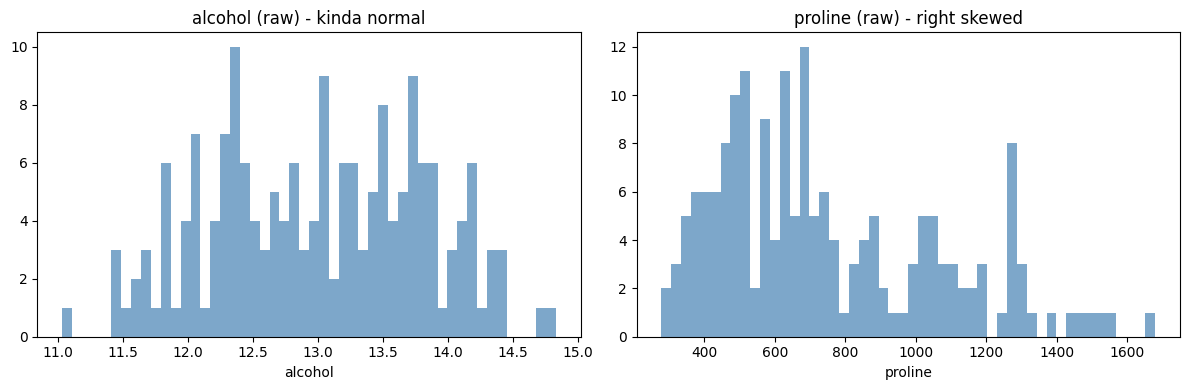

Text(0.5, 0, 'proline')

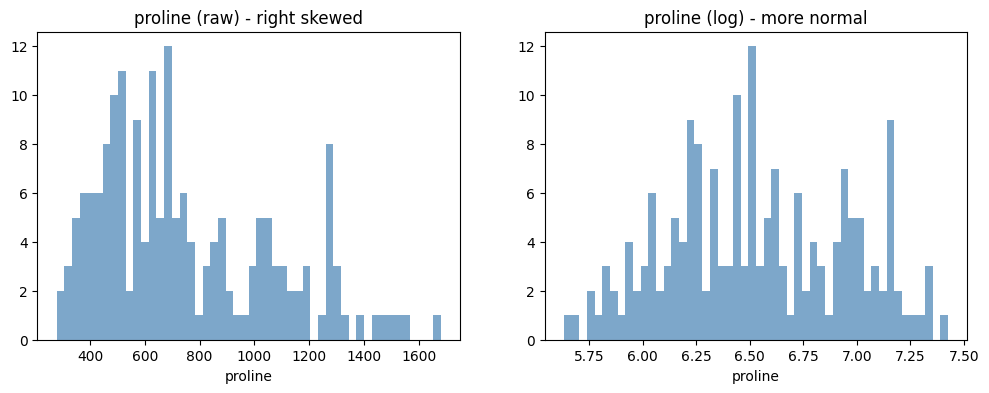

In [15]:
# DO IT YOURSELF - Section 2
# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_wine['alcohol'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('alcohol (raw) - kinda normal')
axes[0].set_xlabel('alcohol')

axes[1].hist(df_wine['proline'], bins=50, color='steelblue', alpha=0.7)
axes[1].set_title('proline (raw) - right skewed')
axes[1].set_xlabel('proline')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_wine['proline'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('proline (raw) - right skewed')
axes[0].set_xlabel('proline')

axes[1].hist(np.log1p(df_wine['proline']), bins=50, color='steelblue', alpha=0.7)
axes[1].set_title('proline (log) - more normal')
axes[1].set_xlabel('proline')

# In terms of shape, yes it does look more normal, but its not a nice normal distribution.

---
## Section 3 - Feature Interactions
### EXAMPLE

In [17]:
# EXAMPLE: manual interaction features on housing data
# Domain knowledge: rooms per person and bedrooms ratio are more meaningful than raw counts

df_feat = df_housing.copy()

# Raw features
X_raw = df_feat[['AveRooms', 'AveBedrms', 'Population', 'AveOccup']]

# Engineered features
df_feat['rooms_per_occup']   = df_feat['AveRooms'] / (df_feat['AveOccup'] + 1)
df_feat['bedroom_ratio']     = df_feat['AveBedrms'] / (df_feat['AveRooms'] + 1)
df_feat['pop_per_occup']     = df_feat['Population'] / (df_feat['AveOccup'] + 1)

X_engineered = df_feat[['AveRooms', 'AveBedrms', 'Population', 'AveOccup',
                          'rooms_per_occup', 'bedroom_ratio', 'pop_per_occup']]
y = df_feat['target']

from sklearn.linear_model import LinearRegression
lr = LinearRegression()

score_raw = cross_val_score(lr, X_raw, y, cv=5, scoring='r2').mean()
score_eng = cross_val_score(lr, X_engineered, y, cv=5, scoring='r2').mean()

print(f'R2 raw features:        {score_raw:.4f}')
print(f'R2 engineered features: {score_eng:.4f}')
print()
print('Engineered features added domain knowledge the model could not learn on its own')

R2 raw features:        0.0250
R2 engineered features: 0.0910

Engineered features added domain knowledge the model could not learn on its own


### DO IT YOURSELF - Section 3
Dataset: wine

1. Create 2 manual interaction features that make domain sense for wine:
   - `alcohol_to_acid` = alcohol / (malic_acid + 1)
   - `flavanoids_to_phenols` = flavanoids / (total_phenols + 1)
2. Train a RandomForest with raw features vs raw + interaction features
3. Compare CV accuracy - did the interactions help?

In [ ]:
# DO IT YOURSELF - Section 3
# YOUR CODE HERE
df_wine_feat  = df_wine.copy()
X_w_raw = df_wine_feat[['alcohol', 'malic_acid', 'flavanoids', 'total_phenols']]

df_wine_feat['alcohol_to_acid'] = df_wine_feat['alcohol'] / (df_wine_feat['malic_acid'] +  1)
df_wine_feat['flavanoids_to_phenols'] = df_wine_feat['flavanoids'] / (df_wine_feat['total_phenols'] + 1)

X_w_engineered = df_wine_feat[['alcohol', 'malic_acid', 'flavanoids', 'total_phenols', 'alcohol_to_acid', 'flavanoids_to_phenols']]

y = df_wine_feat['target']

rf = RandomForestClassifier()
score_raw = cross_val_score(rf, X_w_raw, y, cv=5, scoring='accuracy').mean()
score_eng = cross_val_score(rf, X_w_engineered, y, cv=5, scoring='accuracy').mean()

print(f'accuracy raw features:        {score_raw:.4f}')
print(f'accuracy engineered features: {score_eng:.4f}')
print()

# Actually it seem like engineered features performed slightly worse.

accuracy raw features:        0.9162
accuracy engineered features: 0.9108

Engineered features added domain knowledge the model could not learn on its own


---
## Section 4 - Binning and Datetime Features
### EXAMPLE

In [26]:
# EXAMPLE: binning a continuous feature + datetime extraction

df_ex = df_housing.copy()

# Bin median income into brackets
df_ex['income_bracket'] = pd.cut(
    df_ex['MedInc'],
    bins=[0, 2, 4, 6, 20],
    labels=['low', 'medium', 'high', 'very_high']
)

print('Income distribution by bracket:')
print(df_ex['income_bracket'].value_counts().sort_index())
print()
print('Mean house price by bracket:')
print(df_ex.groupby('income_bracket')['target'].mean().round(2))
print()

# Datetime example
df_dates = pd.DataFrame({
    'timestamp': pd.date_range('2024-01-01', periods=10, freq='13h'),
    'sales': np.random.randint(100, 500, 10)
})

df_dates['hour']       = df_dates['timestamp'].dt.hour
df_dates['day_of_week']= df_dates['timestamp'].dt.dayofweek
df_dates['is_weekend'] = df_dates['day_of_week'].isin([5, 6]).astype(int)

print('Datetime features extracted:')
print(df_dates[['timestamp', 'hour', 'day_of_week', 'is_weekend', 'sales']])

Income distribution by bracket:
income_bracket
low           2457
medium       10096
high          5725
very_high     2362
Name: count, dtype: int64

Mean house price by bracket:
income_bracket
low          1.12
medium       1.68
high         2.45
very_high    3.79
Name: target, dtype: float64

Datetime features extracted:
            timestamp  hour  day_of_week  is_weekend  sales
0 2024-01-01 00:00:00     0            0           0    127
1 2024-01-01 13:00:00    13            0           0    203
2 2024-01-02 02:00:00     2            1           0    429
3 2024-01-02 15:00:00    15            1           0    191
4 2024-01-03 04:00:00     4            2           0    475
5 2024-01-03 17:00:00    17            2           0    458
6 2024-01-04 06:00:00     6            3           0    352
7 2024-01-04 19:00:00    19            3           0    279
8 2024-01-05 08:00:00     8            4           0    335
9 2024-01-05 21:00:00    21            4           0    280


### DO IT YOURSELF - Section 4
Dataset: wine

1. Bin `alcohol` into 3 groups: low (<12), medium (12-13), high (>13)
2. Print the count per group
3. Print the mean target (wine class) per group
4. Comment: does alcohol level seem to separate wine classes?

In [31]:
# DO IT YOURSELF - Section 4
# YOUR CODE HERE
df_wine_ex = df_wine.copy()

df_wine_ex['alcohol_bracket'] = pd.cut(
    df_wine_ex['alcohol'],
    bins=[0, 12, 13, 14],
    labels=['low', 'medium', 'high']
)

print('Alcohol distribution by bracket:')
print(df_wine_ex['alcohol_bracket'].value_counts().sort_index())
print()
print('Mean Alcoohol level by bracket: ')
print(df_wine_ex.groupby('alcohol_bracket')['target'].mean().round(2))

Alcohol distribution by bracket:
alcohol_bracket
low       22
medium    64
high      70
Name: count, dtype: int64

Mean Alcoohol level by bracket: 
alcohol_bracket
low       1.0
medium    1.3
high      0.8
Name: target, dtype: float64


---
## Section 5 - Regularization
### EXAMPLE

In [32]:
# EXAMPLE: L1 vs L2 regularization on logistic regression (breast cancer)
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_c_train_scaled = scaler.fit_transform(X_c_train)
X_c_test_scaled  = scaler.transform(X_c_test)

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

print(f'{"C":>8}  {"L2 (Ridge) CV":>14}  {"L1 (Lasso) CV":>14}')
print('-' * 42)

for C in C_values:
    l2 = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=1000)
    l1 = LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=1000)
    
    l2_cv = cross_val_score(l2, X_c_train_scaled, y_c_train, cv=5, scoring='accuracy').mean()
    l1_cv = cross_val_score(l1, X_c_train_scaled, y_c_train, cv=5, scoring='accuracy').mean()
    
    print(f'{C:>8}  {l2_cv:>14.4f}  {l1_cv:>14.4f}')

print()
print('Small C = strong regularization (more penalty)')
print('Large C = weak regularization (less penalty)')

       C   L2 (Ridge) CV   L1 (Lasso) CV
------------------------------------------
   0.001          0.8879          0.3714
    0.01          0.9451          0.9055
     0.1          0.9714          0.9670
       1          0.9736          0.9780
      10          0.9758          0.9626
     100          0.9582          0.9582

Small C = strong regularization (more penalty)
Large C = weak regularization (less penalty)


In [33]:
# EXAMPLE: L1 drives weights to zero (feature selection)

l1_strong = LogisticRegression(C=0.01, penalty='l1', solver='liblinear', max_iter=1000)
l1_strong.fit(X_c_train_scaled, y_c_train)

weights = l1_strong.coef_[0]
n_zero = np.sum(weights == 0)

print(f'Total features: {len(weights)}')
print(f'Weights driven to zero by L1: {n_zero}')
print(f'Features still active: {len(weights) - n_zero}')
print()
print('L1 automatically selected the most important features')

Total features: 30
Weights driven to zero by L1: 27
Features still active: 3

L1 automatically selected the most important features


### DO IT YOURSELF - Section 5
Dataset: wine

1. Scale the wine data
2. Try L2 logistic regression with `C = 0.01, 0.1, 1, 10` - print CV accuracy for each
3. Try L1 logistic regression with the same C values
4. For the best L1 C value, print how many weights were driven to zero
5. Comment: which C value worked best and why?

In [ ]:
# DO IT YOURSELF - Section 5
# YOUR CODE HERE
wine = load_wine()
X_w, y_w = wine.data, wine.target
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(X_w, y_w, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_w_train_scaled = scaler.fit_transform(X_w_train)

C_values = [0.01, 0.1, 1, 10]

print(f'{"C":>8}  {"L2 (Ridge) CV":>14}  {"L1 (Lasso) CV":>14}')
print('-' * 42)

for C in C_values:
    l2 = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=1000)
    l1 = LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=1000)
    
    l2_cv = cross_val_score(l2, X_w_train_scaled, y_w_train, cv=5, scoring='accuracy').mean()
    l1_cv = cross_val_score(l1, X_w_train_scaled, y_w_train, cv=5, scoring='accuracy').mean()
    
    print(f'{C:>8}  {l2_cv:>14.4f}  {l1_cv:>14.4f}')

print()
print('Small C = strong regularization (more penalty)')
print('Large C = weak regularization (less penalty)')

# For L1 best C value is 1
l1_strong = LogisticRegression(C=1, penalty='l1', solver='liblinear', max_iter=1000)
l1_strong.fit(X_w_train_scaled, y_w_train)

weights = l1_strong.coef_[0]
n_zero = np.sum(weights == 0)

print(f'Total features: {len(weights)}')
print(f'Weights driven to zero by L1: {n_zero}')
print(f'Features still active: {len(weights) - n_zero}')
print()
print('L1 automatically selected the most important features')

# Based on previous table looks like C=1 gives best result for accuracy. 
# as for 0.01, when train and get total active feature, it become 0 which suggest that 0.01 is too big regularizatioin stength that underfits

#

       C   L2 (Ridge) CV   L1 (Lasso) CV
------------------------------------------
    0.01          0.9714          0.3170
     0.1          0.9929          0.9576
       1          0.9791          0.9648
      10          0.9791          0.9579

Small C = strong regularization (more penalty)
Large C = weak regularization (less penalty)
Total features: 13
Weights driven to zero by L1: 6
Features still active: 7

L1 automatically selected the most important features


---
## Section 6 - Feature Selection
### EXAMPLE

In [43]:
# EXAMPLE: SelectKBest vs RFE on breast cancer
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif, RFE

cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

# All features baseline
rf = RandomForestClassifier(n_estimators=100, random_state=42)
baseline = cross_val_score(rf, X_c_train, y_c_train, cv=5, scoring='accuracy').mean()

# SelectKBest: keep top 10 features by statistical test
selector = SelectKBest(f_classif, k=10)
X_kbest = selector.fit_transform(X_c_train, y_c_train)
kbest_score = cross_val_score(rf, X_kbest, y_c_train, cv=5, scoring='accuracy').mean()

selected_features = cancer.feature_names[selector.get_support()]

# RFE: recursively eliminate least important features
rfe = RFE(RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=10)
X_rfe = rfe.fit_transform(X_c_train, y_c_train)
rfe_score = cross_val_score(rf, X_rfe, y_c_train, cv=5, scoring='accuracy').mean()

print(f'Baseline (all 30 features): {baseline:.4f}')
print(f'SelectKBest (top 10):       {kbest_score:.4f}')
print(f'RFE (top 10):               {rfe_score:.4f}')
print()
print('Features selected by SelectKBest:')
print(selected_features)

Baseline (all 30 features): 0.9582
SelectKBest (top 10):       0.9473
RFE (top 10):               0.9714

Features selected by SelectKBest:
['mean radius' 'mean perimeter' 'mean area' 'mean concavity'
 'mean concave points' 'worst radius' 'worst perimeter' 'worst area'
 'worst concavity' 'worst concave points']


### DO IT YOURSELF - Section 6
Dataset: wine

1. Use SelectKBest with k=5 to select the top 5 features
2. Print which features were selected
3. Compare CV accuracy: all 13 features vs top 5 selected
4. Comment: did removing features hurt or help?

In [51]:
# DO IT YOURSELF - Section 6
# YOUR CODE HERE
wine = load_wine()
X_w, y_w = wine.data, wine.target
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(X_w, y_w, test_size=0.2, random_state=42)

# SelectKBest: keep top 10 features by statistical test
rf = RandomForestClassifier(n_estimators=100, random_state=42)
baseline = cross_val_score(rf, X_w_train, y_w_train, cv=5, scoring='accuracy').mean()
selector = SelectKBest(f_classif, k=10)
X_kbest = selector.fit_transform(X_w_train, y_w_train)
kbest_score = cross_val_score(rf, X_kbest, y_w_train, cv=5, scoring='accuracy').mean()


selected_features = np.array(wine.feature_names)[selector.get_support()]

print('Features selected by SelectKBest:')
print(selected_features)
print()
print(f'Baseline (all features): {baseline:.4f}')
print(f'SelectKBest (top 10):       {kbest_score:.4f}')

# actually removing feature work the accuracy slightly, which suggest that all featuures matter to target to some meaning extent

Features selected by SelectKBest:
['alcohol' 'malic_acid' 'alcalinity_of_ash' 'total_phenols' 'flavanoids'
 'proanthocyanins' 'color_intensity' 'hue' 'od280/od315_of_diluted_wines'
 'proline']

Baseline (all features): 0.9786
SelectKBest (top 10):       0.9645


---
## CAPSTONE

Build a full feature engineering pipeline on the wine dataset:

1. Start with baseline: RandomForest on raw features, print CV accuracy
2. Add log transform to `proline` (right-skewed feature)
3. Add 2 interaction features: `alcohol_to_acid` and `flavanoids_to_phenols`
4. Apply SelectKBest to keep top 8 features from the engineered set
5. Train RandomForest on the final feature set, print CV accuracy
6. Compare all versions (baseline, +log, +interactions, +selection) in one table
7. Written answer: which engineering step helped most and why?

In [66]:
# CAPSTONE
# YOUR CODE HERE
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target
X_w_raw, y_w_raw = df_wine[wine.feature_names], df_wine['target']
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(X_w_raw, y_w_raw, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Baseline
baseline = cross_val_score(rf, X_w_train, y_w_train, cv=5, scoring='accuracy').mean()

# log transform
df_wine_log = df_wine.copy()
df_wine_log['proline'] = np.log1p(df_wine_log['proline'])
X_w_log = df_wine_log[wine.feature_names]
X_w_log_train, X_w_log_test, y_w_log_train, y_w_log_test = train_test_split(X_w_log, y_w_raw, test_size=0.2, random_state=42)

log_transform = cross_val_score(rf, X_w_log_train, y_w_log_train, cv=5, scoring='accuracy').mean()

# Interaction
df_wine_int = df_wine.copy()
df_wine_int['alcohol_to_acid'] = df_wine_int['alcohol'] / (df_wine_int['malic_acid'] +  1)
df_wine_int['flavanoids_to_phenols'] = df_wine_int['flavanoids'] / (df_wine_int['total_phenols'] + 1)
X_w_int = df_wine_int[list(wine.feature_names) + ['alcohol_to_acid', 'flavanoids_to_phenols']]
X_w_int_train, X_w_int_test, y_w_int_train, y_w_int_test = train_test_split(X_w_int, y_w_raw, test_size=0.2, random_state=42)

int_transform = cross_val_score(rf, X_w_int_train, y_w_int_train, cv=5, scoring='accuracy').mean()

# SelectKBest
selector = SelectKBest(f_classif, k=10)
X_kbest = selector.fit_transform(X_w_train, y_w_train)
kbest_score = cross_val_score(rf, X_kbest, y_w_train, cv=5, scoring='accuracy').mean()


print('Version                       CV Accuracy')
print('-----------------------------------------')
print(f'baseline:                     {baseline}')
print(f'baseline + log:               {log_transform}')
print(f'baseline + int:               {int_transform}')
print(f'baseline + SelectKBest:       {kbest_score}')

# None of them really helps because for log and int, this doesnt make sense on random decision tree for following reasons
# 1. rf does not rely on normal distribution
# 2. interaction does not provide new data just variation of known data,  so when tree splits, direction to leaf will still be the same
# SelectKBest actually decrease the accuracy slightly which suggests that all features matters when determining target in meaningful ways


Version                       CV Accuracy
-----------------------------------------
baseline:                     0.9785714285714286
baseline + log:               0.9785714285714286
baseline + int:               0.9785714285714286
baseline + SelectKBest:       0.9645320197044336
